<a href="https://colab.research.google.com/github/DigiBP/AS25_Lotschberger/blob/main/notebooks/Explainable_start_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Execute this code only if in colab
if 'COLAB_GPU' in os.environ:
  print("Executing in Colab!")
  # Cloning GitHub repository
  !git clone https://github.com/fwitschel/HCIBM.git
  %cd HCIBM


Executing in Colab!
Cloning into 'HCIBM'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 93 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 386.66 KiB | 6.44 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/HCIBM


# Library imports

In [2]:
!pip install lime
!pip install imodels

import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lime
import lime.lime_tabular
from xgboost import XGBClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn import tree
from imodels import RuleFitRegressor
from imodels import RuleFitClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import warnings
# suppresses deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b0d9f61e2866a84f914081510554a7e7318f9b2ebaa630c45fd374b9de3d2949
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.5/274.5 kB 6.0 MB/s eta 0:00:00


# Data loading and cleaning

The first step is loading the dataset

In [3]:
# load the data
data = pd.read_csv('/content/HCIBM/datasets/Myocardial infarction complications Database.csv')

These columns are removed as they refer to other complications that in this teaching case won't be used.

In [4]:
# remove the columns corresponding to other complications that we do not want to predict
data = data.drop('KFK_BLOOD', axis=1)
data = data.drop('IBS_NASL', axis=1)
data = data.drop('LET_IS', axis=1)
data = data.drop('P_IM_STEN', axis=1)
data = data.drop('REC_IM', axis=1)
data = data.drop('DRESSLER', axis=1)
data = data.drop('RAZRIV', axis=1)
data = data.drop('OTEK_LANC', axis=1)
data = data.drop('A_V_BLOK', axis=1)
data = data.drop('FIBR_JELUD', axis=1)
data = data.drop('JELUD_TAH', axis=1)
data = data.drop('PREDS_TAH', axis=1)
data = data.drop('FIBR_PREDS', axis=1)
data = data.drop('ID', axis=1)

# we additionally drop some columns where a lot of values are missing
# (makes performance of models better...)
data = data.drop('S_AD_KBRIG', axis=1)
data = data.drop('D_AD_KBRIG', axis=1)
data = data.drop('NOT_NA_KB', axis=1)
data = data.drop('LID_KB', axis=1)
data = data.drop('NA_KB', axis=1)
data = data.drop('GIPO_K', axis=1)

In [5]:
# set target and one-hot encode categorical stuff:
X = data.drop('ZSN', axis=1)
one_hot_X = pd.get_dummies(X)
y = data.ZSN

In [6]:
# train-test split and fitting an XGBoost model
X_train, X_test, y_train, y_test = train_test_split(one_hot_X, y, test_size=0.2)
model = XGBClassifier()
model.fit(X_train.values, y_train.values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
from sklearn.inspection import permutation_importance
r = permutation_importance(model, X_test.values, y_test.values,
                           n_repeats=30,
                           random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{X_test.columns[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

ZSN_A   0.056 +/- 0.011
K_BLOOD 0.012 +/- 0.006
FK_STENOK0.009 +/- 0.004


ZSN_A 0.056 = durchschn. Rückgang/Fehleranstieg. Je höher die Zahl desto wichtiger Feature. +/- 0.011 = Standardabweichung


In [ ]:
r = permutation_importance(model, X_test.values, y_test.values,
                           n_repeats=30,
                           random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{X_test.columns[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

/tmp/ipykernel_3426/3605807264.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance_mean', y='feature', data=perm_importance_df_sorted,


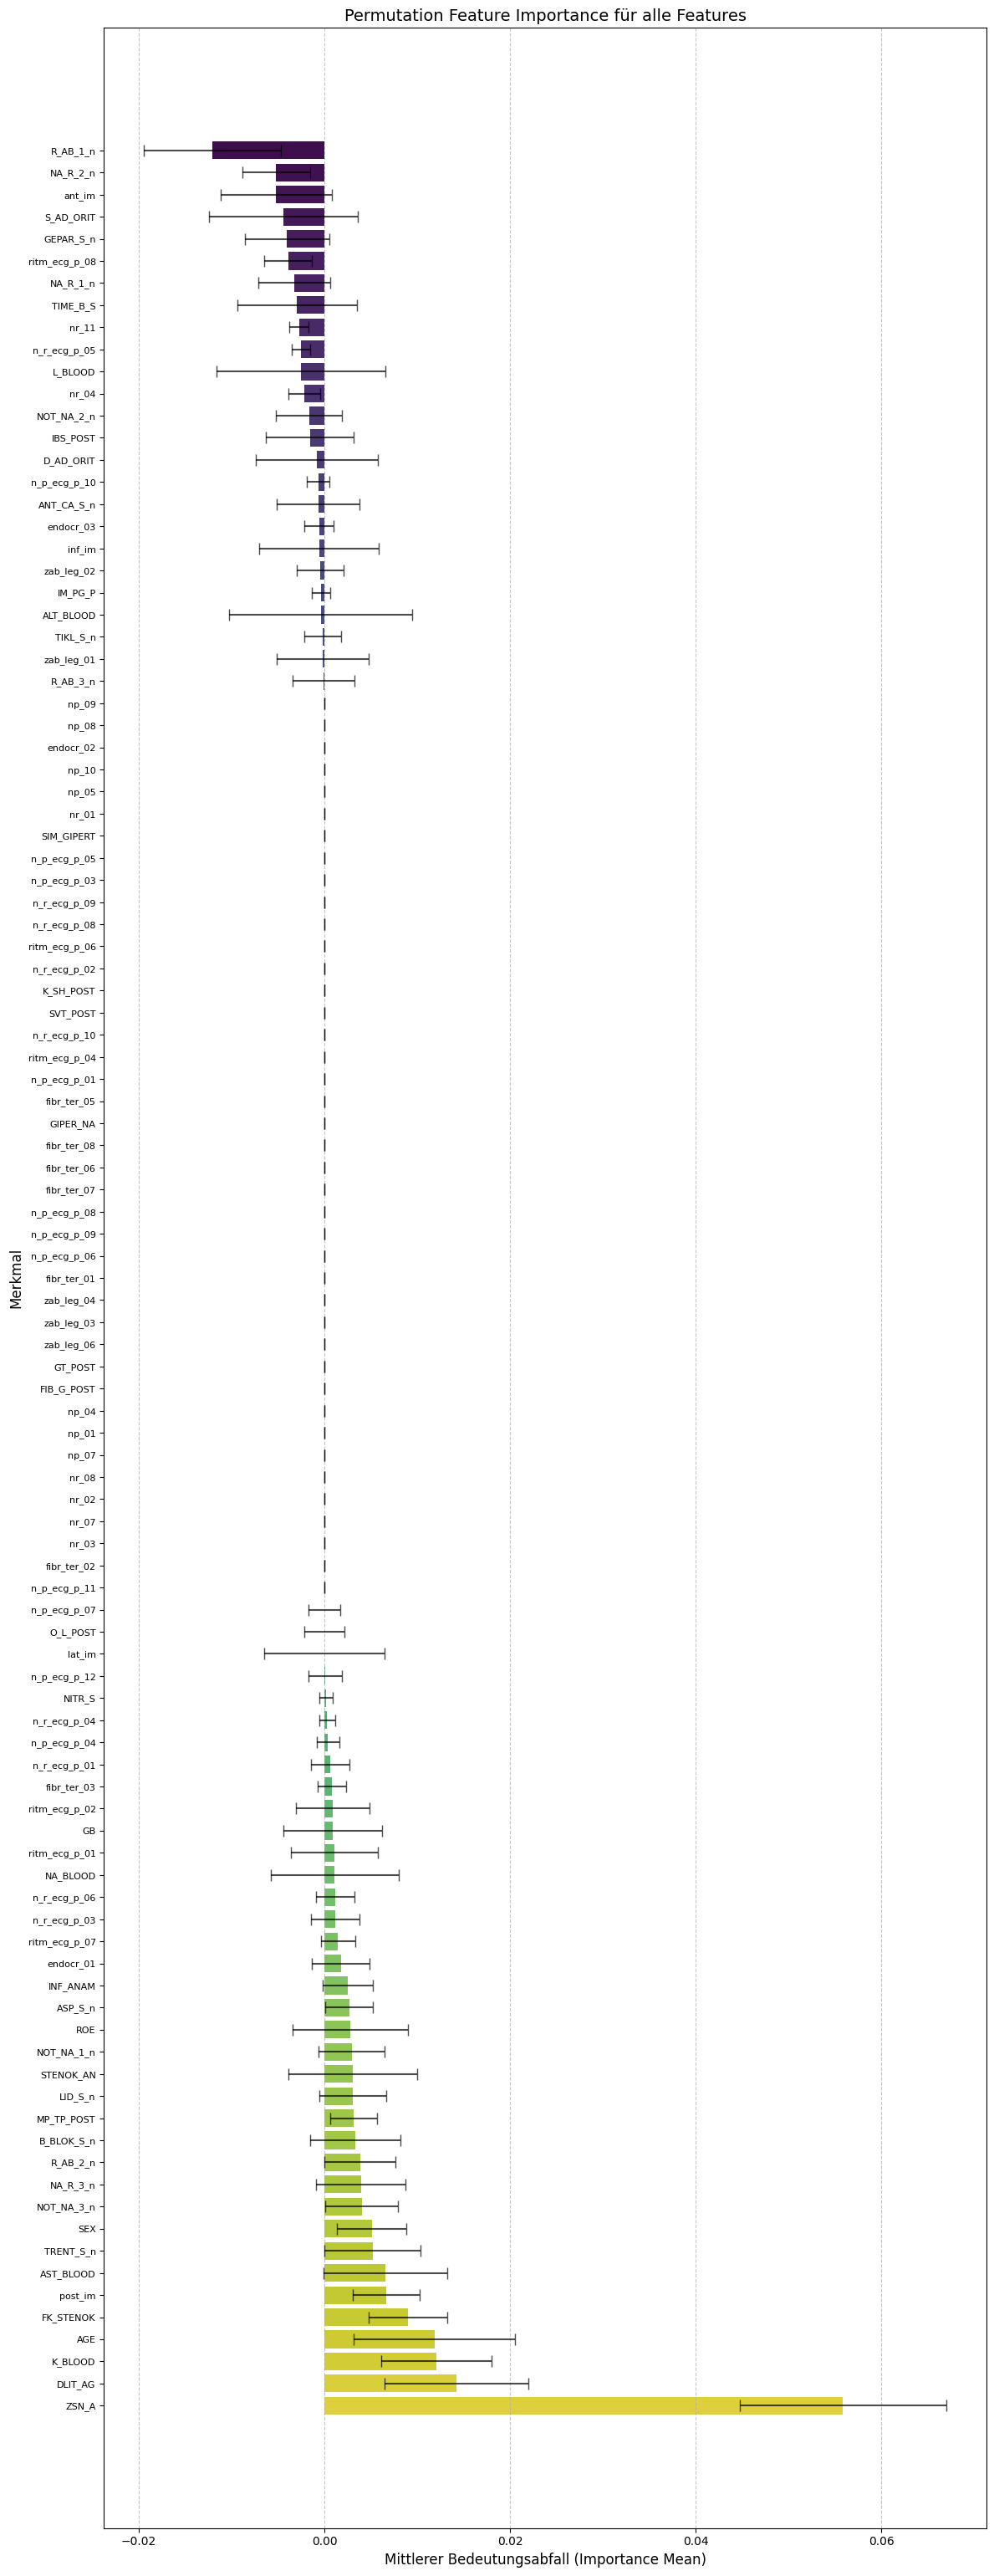

In [19]:
if 'r' in globals() and 'X_test' in globals():
    perm_importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': r.importances_mean,
        'importance_std': r.importances_std
    })
else:
    print("Error: 'r' or 'X_test' not found. Please ensure permutation importance has been run.")
    # Fallback or raise an error if permutation importance was not run.
    # For this task, assume 'r' and 'X_test' are available from previous steps.

# Sort features by importance for better visualization
perm_importance_df_sorted = perm_importance_df.sort_values(by='importance_mean', ascending=True) # Sort ascending for horizontal bar plot (bottom to top)

plt.figure(figsize=(12, max(6, len(perm_importance_df_sorted) * 0.3))) # Adjust figure size dynamically
ax = sns.barplot(x='importance_mean', y='feature', data=perm_importance_df_sorted,
            palette='viridis') # Plot bars without xerr initially

# Manually add error bars
x_coords = perm_importance_df_sorted['importance_mean']
y_coords = np.arange(len(perm_importance_df_sorted['feature']))
xerr_values = perm_importance_df_sorted['importance_std']

ax.errorbar(x=x_coords, y=y_coords, xerr=xerr_values, fmt='none', capsize=5, color='black', alpha=0.7)

plt.title('Permutation Feature Importance für alle Features', fontsize=14)
plt.xlabel('Mittlerer Bedeutungsabfall (Importance Mean)', fontsize=12)
plt.ylabel('Merkmal', fontsize=12)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=8) # Smaller labels for potentially many features
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3426/1923825754.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance_mean', y='feature', data=significant_features_df,


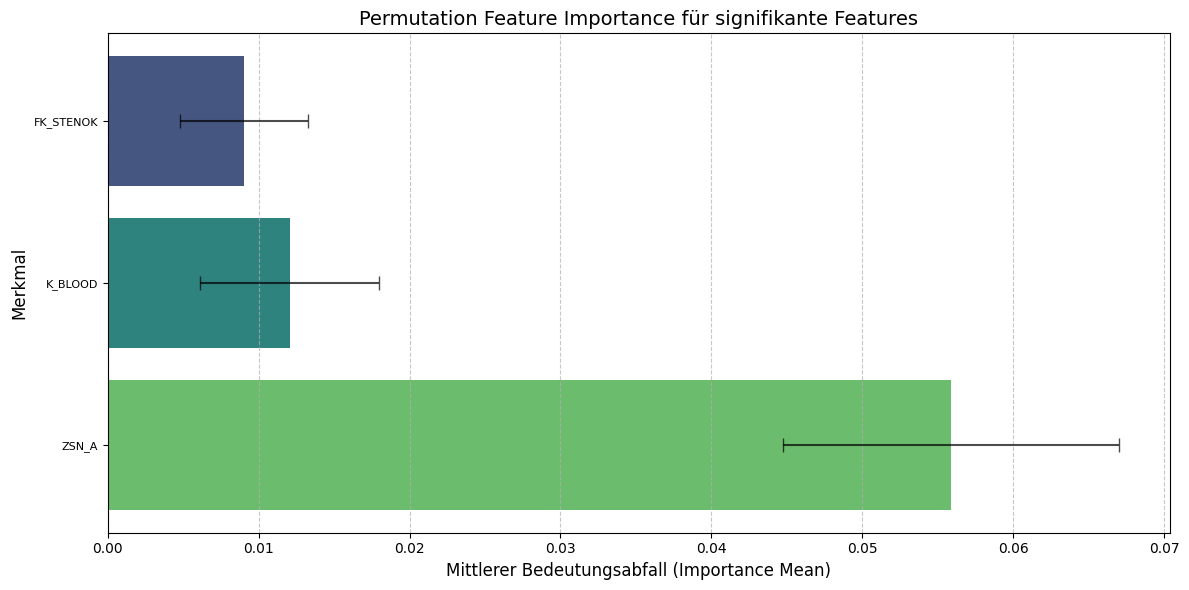

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure perm_importance_df is available, recreating if necessary
# (It should be available from previous runs, but for robustness)
if 'r' in globals() and 'X_test' in globals():
    perm_importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': r.importances_mean,
        'importance_std': r.importances_std
    })
else:
    print("Error: 'r' or 'X_test' not found. Please ensure permutation importance has been run.")
    # Fallback or raise an error if permutation importance was not run.
    # For this task, assume 'r' and 'X_test' are available from previous steps.

# Filter for significant features (where mean importance - 2*std > 0)
significant_features_df = perm_importance_df[
    perm_importance_df['importance_mean'] - 2 * perm_importance_df['importance_std'] > 0
].sort_values(by='importance_mean', ascending=True) # Sort ascending for horizontal bar plot (bottom to top)

plt.figure(figsize=(12, max(6, len(significant_features_df) * 0.3))) # Adjust figure size dynamically
ax = sns.barplot(x='importance_mean', y='feature', data=significant_features_df,
            palette='viridis') # Plot bars without xerr initially

# Manually add error bars
x_coords = significant_features_df['importance_mean']
y_coords = np.arange(len(significant_features_df['feature']))
xerr_values = significant_features_df['importance_std']

ax.errorbar(x=x_coords, y=y_coords, xerr=xerr_values, fmt='none', capsize=5, color='black', alpha=0.7)

plt.title('Permutation Feature Importance für signifikante Features', fontsize=14)
plt.xlabel('Mittlerer Bedeutungsabfall (Importance Mean)', fontsize=12)
plt.ylabel('Merkmal', fontsize=12)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=8) # Smaller labels for potentially many features
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

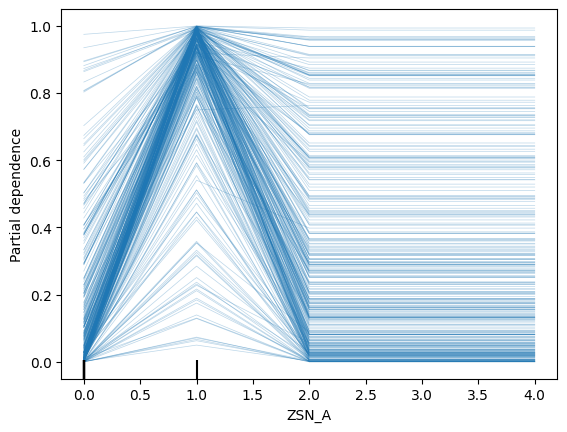

In [25]:
feature_index_ZSN_A = X_test.columns.get_loc('ZSN_A')
features = [feature_index_ZSN_A]
PartialDependenceDisplay.from_estimator(model, X_test, features, kind="individual", target=1)

In [37]:
feature_index_ZSN_A = X_test.columns.get_loc('ZSN_A')
features = [feature_index_ZSN_A]
pdp_display_ZSN_A = PartialDependenceDisplay.from_estimator(model, X_test, features, kind="individual", target=1, categorical_features=[feature_index_ZSN_A])
pdp_display_ZSN_A.figure_.suptitle("Partial Dependence Plot for ZSN_A (Target=1)")
plt.show()

ValueError: It is not possible to display individual effects for categorical features.

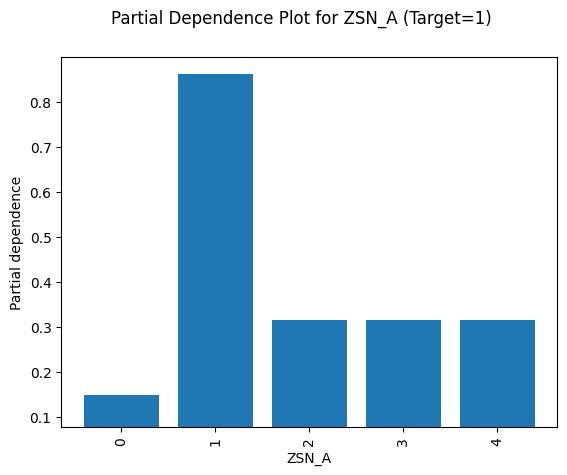

In [38]:
feature_index_ZSN_A = X_test.columns.get_loc('ZSN_A')
features = [feature_index_ZSN_A]
pdp_display_ZSN_A = PartialDependenceDisplay.from_estimator(model, X_test, features, kind="average", target=1, categorical_features=[feature_index_ZSN_A])
pdp_display_ZSN_A.figure_.suptitle("Partial Dependence Plot for ZSN_A (Target=1)")
plt.show()

### Partial Dependence Plot for K_BLOOD

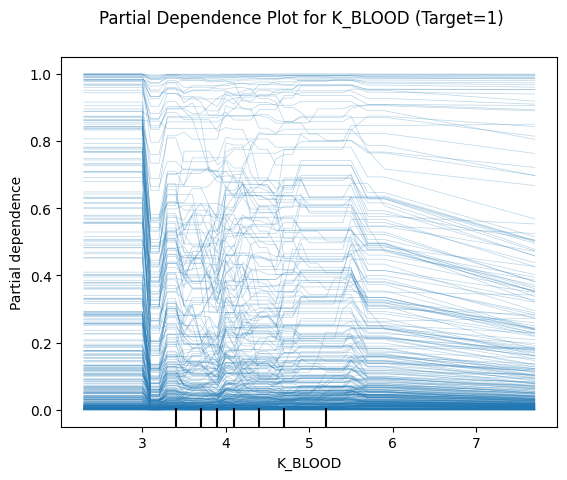

In [39]:
feature_index_K_BLOOD = X_test.columns.get_loc('K_BLOOD')
features_K_BLOOD = [feature_index_K_BLOOD]
pdp_display_K_BLOOD = PartialDependenceDisplay.from_estimator(model, X_test, features_K_BLOOD, kind="individual", target=1)
pdp_display_K_BLOOD.figure_.suptitle("Partial Dependence Plot for K_BLOOD (Target=1)")
plt.show()

### Partial Dependence Plot for FK_STENOK

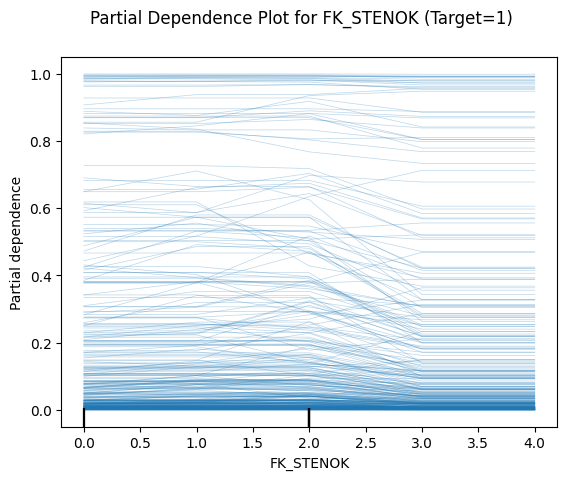

In [40]:
feature_index_FK_STENOK = X_test.columns.get_loc('FK_STENOK')
features_FK_STENOK = [feature_index_FK_STENOK]
pdp_display_FK_STENOK = PartialDependenceDisplay.from_estimator(model, X_test, features_FK_STENOK, kind="individual", target=1)
pdp_display_FK_STENOK.figure_.suptitle("Partial Dependence Plot for FK_STENOK (Target=1)")
plt.show()